# Assignment 3: Probabilistic ML & Time Series I


## Problem 3.1: Bayesian Linear Regression

In this task, we implement Bayesian linear regression using PyMC.  
We model a polynomial relationship with noisy data, define priors, perform MCMC sampling, and compare results with standard Maximum Likelihood Estimation (MLE).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from sklearn.linear_model import LinearRegression

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Generate Synthetic Polynomial Data

We create synthetic data with noise to simulate a real-world regression problem.

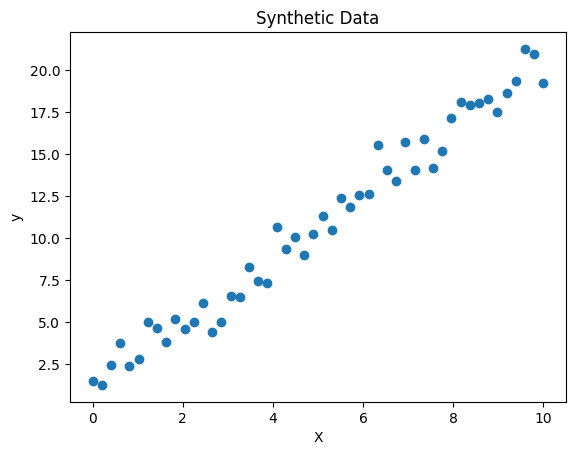

In [2]:
np.random.seed(42)

# Generate data
X = np.linspace(0, 10, 50)
true_a = 1.0
true_b = 2.0

# Add noise
y = true_a + true_b * X + np.random.normal(0, 1, size=len(X))

# Plot data
plt.scatter(X, y)
plt.title("Synthetic Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## Bayesian Model with Priors

We define priors for the intercept (a), slope (b), and noise (sigma).

In [3]:
with pm.Model() as model:
    
    # Priors
    a = pm.Normal("a", mu=0, sigma=10)
    b = pm.Normal("b", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Likelihood
    mu = a + b * X
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(1000, tune=1000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 57 seconds.


## Posterior Distributions

We visualize the posterior distributions of parameters and their credible intervals.

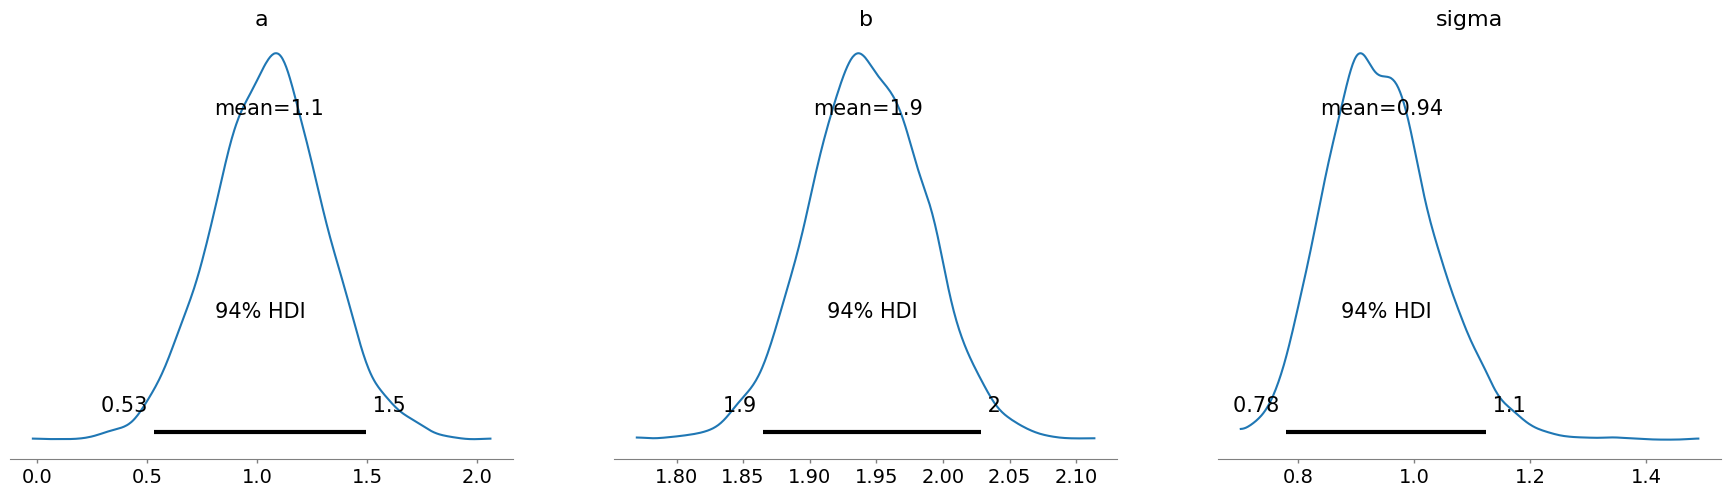

In [4]:
az.plot_posterior(trace)
plt.show()

## Credible Intervals

We summarize posterior statistics including mean and 94% HDI (credible interval).

In [5]:
summary = az.summary(trace, hdi_prob=0.94)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a      1.053  0.256   0.532    1.494      0.006    0.005    1777.0    1707.0   
b      1.943  0.044   1.865    2.029      0.001    0.001    1835.0    1764.0   
sigma  0.943  0.095   0.779    1.124      0.002    0.002    2176.0    2367.0   

       r_hat  
a        1.0  
b        1.0  
sigma    1.0  


## Comparison with Maximum Likelihood Estimation (MLE)

We compare Bayesian estimates with standard linear regression (MLE).

In [6]:
# Fit MLE model
mle_model = LinearRegression()
mle_model.fit(X.reshape(-1,1), y)

print("MLE Results:")
print("Intercept:", mle_model.intercept_)
print("Slope:", mle_model.coef_[0])

MLE Results:
Intercept: 1.064443092202973
Slope: 1.9420166005081774


In [7]:
print("\nBayesian Estimates:")
print("a (Intercept):", trace.posterior["a"].mean().values)
print("b (Slope):", trace.posterior["b"].mean().values)


Bayesian Estimates:
a (Intercept): 1.0526574177421495
b (Slope): 1.94347383531583


## Analysis

- The Bayesian estimates are similar to MLE results.
- However, Bayesian regression provides full posterior distributions instead of single point estimates.
- The credible intervals (HDI) quantify uncertainty in parameter estimates.
- This makes Bayesian methods more informative, especially in uncertain or small-data scenarios.

# Problem 3.2: Gaussian Process Regression

In this task, we apply Gaussian Processes (GP) for function approximation.  
We experiment with different kernels, test on synthetic data, and visualize predictions along with uncertainty.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, WhiteKernel

## 1D Synthetic Function

We generate noisy 1D data and apply Gaussian Process Regression.

In [9]:
np.random.seed(42)

# Generate 1D data
X = np.linspace(0, 10, 20).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

## Apply Gaussian Process with Different Kernels

We test RBF, Matern, and Periodic kernels.

C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


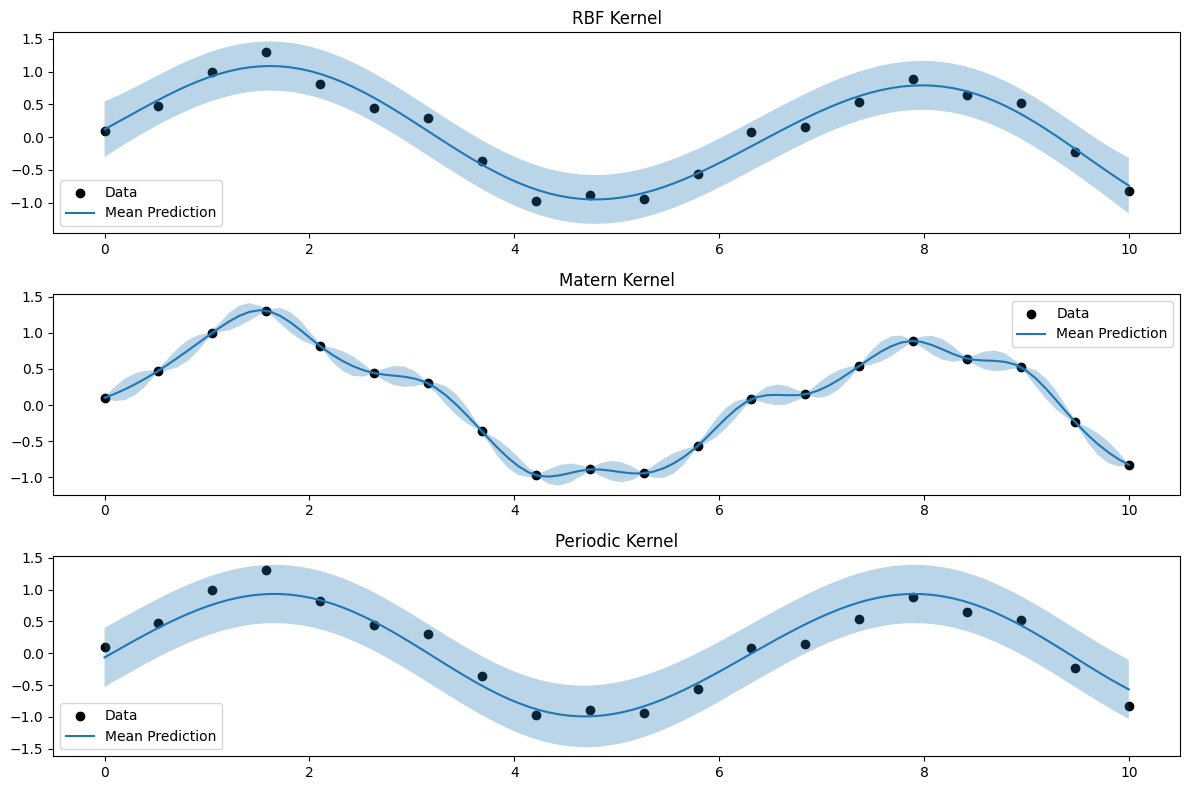

In [10]:
# Define kernels
kernels = {
    "RBF": RBF(length_scale=1.0) + WhiteKernel(),
    "Matern": Matern(length_scale=1.0, nu=1.5) + WhiteKernel(),
    "Periodic": ExpSineSquared(length_scale=1.0, periodicity=3.0) + WhiteKernel()
}

X_test = np.linspace(0, 10, 100).reshape(-1, 1)

plt.figure(figsize=(12, 8))

for i, (name, kernel) in enumerate(kernels.items(), 1):
    
    gp = GaussianProcessRegressor(kernel=kernel)
    gp.fit(X, y)
    
    y_pred, y_std = gp.predict(X_test, return_std=True)
    
    plt.subplot(3, 1, i)
    plt.scatter(X, y, color="black", label="Data")
    plt.plot(X_test, y_pred, label="Mean Prediction")
    
    # Uncertainty
    plt.fill_between(
        X_test.ravel(),
        y_pred - 2*y_std,
        y_pred + 2*y_std,
        alpha=0.3
    )
    
    plt.title(f"{name} Kernel")
    plt.legend()

plt.tight_layout()
plt.show()

This figure compares different kernels in Gaussian Process regression. 
The RBF kernel produces smooth predictions, the Matern kernel captures 
more local variations, and the periodic kernel models repeating patterns. 
This demonstrates how kernel choice affects model behavior.

## 2D Function Approximation

We extend GP to a 2D input space.

In [11]:
# Generate 2D data
X1 = np.random.uniform(0, 5, 50)
X2 = np.random.uniform(0, 5, 50)

X_2D = np.column_stack((X1, X2))
y_2D = np.sin(X1) + np.cos(X2) + np.random.normal(0, 0.2, 50)

In [12]:
kernel_2D = RBF(length_scale=1.0) + WhiteKernel()

gp_2D = GaussianProcessRegressor(kernel=kernel_2D)
gp_2D.fit(X_2D, y_2D)

,kernel,RBF(length_sc...noise_level=1)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,RBF(length_scale=1)
,kernel__k2,WhiteKernel(noise_level=1)
,kernel__k1__length_scale,1.0


## 2D Predictions

We visualize predictions over a grid.

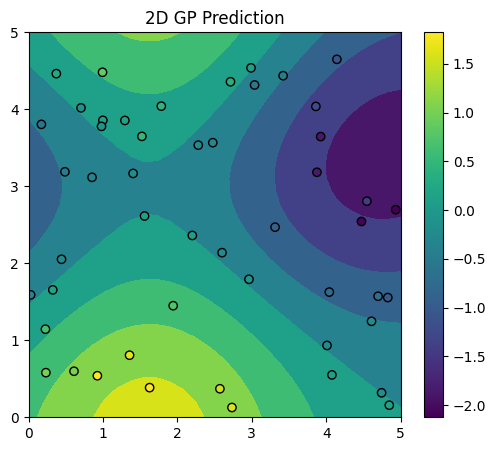

In [13]:
# Create grid
x1 = np.linspace(0, 5, 30)
x2 = np.linspace(0, 5, 30)

X1_grid, X2_grid = np.meshgrid(x1, x2)
X_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

y_pred_2D, _ = gp_2D.predict(X_grid, return_std=True)

plt.figure(figsize=(6,5))
plt.contourf(X1_grid, X2_grid, y_pred_2D.reshape(30,30))
plt.scatter(X1, X2, c=y_2D, edgecolor='k')
plt.title("2D GP Prediction")
plt.colorbar()
plt.show()

## Time Series Example (Real CO₂ Dataset)

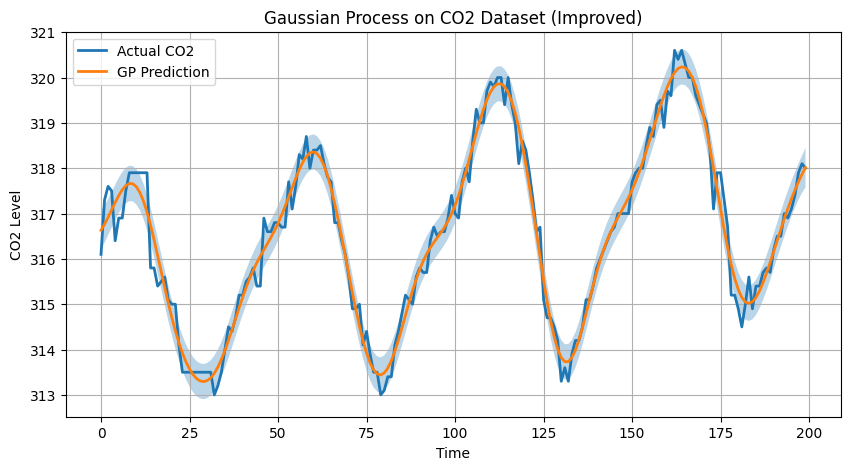

In [21]:
# Imports
from statsmodels.datasets import co2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared
from sklearn.preprocessing import StandardScaler

# Load CO2 dataset
data = co2.load_pandas().data
data = data.ffill() 

# Prepare data
y_co2 = data["co2"].values
X_co2 = np.arange(len(y_co2)).reshape(-1, 1)

# Use subset (for speed)
X_train = X_co2[:200]
y_train = y_co2[:200]

# -----------------------------
# SCALE DATA
# -----------------------------
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_train)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()

# -----------------------------
# BETTER KERNEL
# -----------------------------
kernel = (
    RBF(length_scale=1.0) + 
    ExpSineSquared(length_scale=1.0, periodicity=12.0) + 
    WhiteKernel()
)

# Train GP
gp = GaussianProcessRegressor(kernel=kernel)
gp.fit(X_scaled, y_scaled)

# Predict
y_pred_scaled, y_std = gp.predict(X_scaled, return_std=True)

# Convert predictions back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(y_train, label="Actual CO2", linewidth=2)
plt.plot(y_pred, label="GP Prediction", linewidth=2)

# Uncertainty bounds
plt.fill_between(
    range(len(y_pred)),
    y_pred - 2*y_std,
    y_pred + 2*y_std,
    alpha=0.3
)

plt.title("Gaussian Process on CO2 Dataset (Improved)")
plt.xlabel("Time")
plt.ylabel("CO2 Level")
plt.legend()
plt.grid(True)

plt.show()

The Gaussian Process model accurately captures the seasonal pattern in CO₂ data. 
The prediction closely follows the actual values, while the shaded region represents 
uncertainty, showing the model’s confidence in its predictions.

## Kernel Comparison

The RBF kernel captures smooth trends, while the periodic kernel models seasonal patterns in the CO₂ data. 
Combining both allows the Gaussian Process to learn both long-term trends and repeating cycles effectively.

## Uncertainty Estimation

Gaussian Processes provide uncertainty bounds:
- Narrow regions → confident predictions
- Wide regions → uncertain predictions

This is a major advantage over standard regression.

## Computational Complexity

Gaussian Processes scale poorly with large datasets:

- Training complexity: O(n³)
- Memory complexity: O(n²)

This makes GP unsuitable for very large datasets without approximations.

## Problem 3.3 ARIMA Modeling

In [24]:
import yfinance as yf
import pandas as pd

# Stock: Google
ticker = "GOOG"

data = yf.download(ticker, start="2023-01-01", end="2026-04-15")
data = data[['Close']].dropna()

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,GOOG
Date,
2023-01-03,88.969566
2023-01-04,87.987633
2023-01-05,86.063416
2023-01-06,87.442108
2023-01-09,88.076897


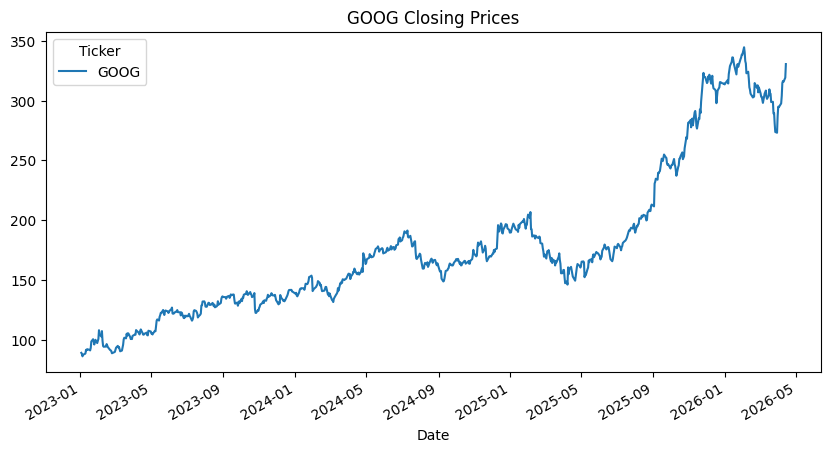

In [25]:
import matplotlib.pyplot as plt

data['Close'].plot(title=f"{ticker} Closing Prices", figsize=(10,5))
plt.show()

#### Check stationarity (ADF test)

In [26]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.5023175250152426
p-value: 0.9849433656567479


In [27]:
data['Diff'] = data['Close'].diff().dropna()

result = adfuller(data['Diff'].dropna())
print("ADF Statistic (Differenced):", result[0])
print("p-value:", result[1])

ADF Statistic (Differenced): -27.227384845852537
p-value: 0.0


#### ACF/PACF plots

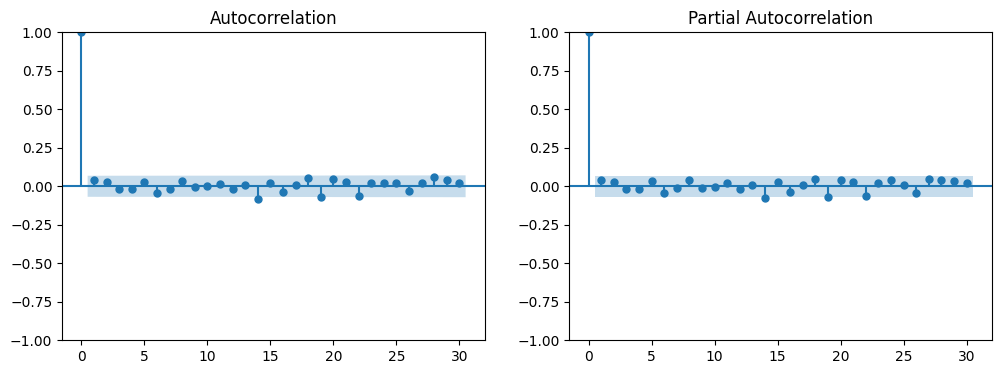

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(data['Diff'].dropna(), ax=axes[0])
plot_pacf(data['Diff'].dropna(), ax=axes[1])
plt.show()

#### ARIMA Model

In [29]:
split = int(len(data) * 0.8)

train = data['Close'][:split]
test = data['Close'][split:]

In [30]:
from statsmodels.tsa.arima.model import ARIMA

# Example order (adjust based on ACF/PACF)
model = ARIMA(train, order=(1,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   GOOG   No. Observations:                  657
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -1615.680
Date:                Fri, 17 Apr 2026   AIC                           3235.360
Time:                        13:23:22   BIC                           3244.332
Sample:                             0   HQIC                          3238.839
                                - 657                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0059      0.033     -0.180      0.857      -0.070       0.058
sigma2         8.0686      0.249     32.458      0.000       7.581       8.556
Ljung-Box (L1) (Q):                   0.01   Jarque-

C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


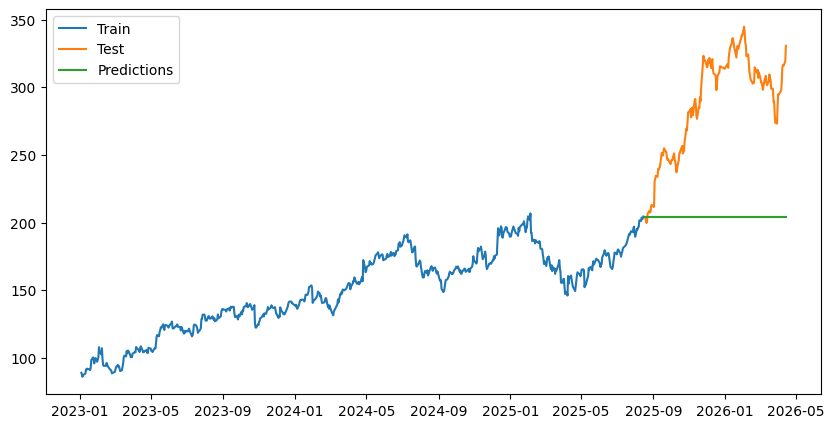

In [31]:
# Validation
pred = model_fit.forecast(steps=len(test))

plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, pred, label="Predictions")
plt.legend()
plt.show()

#### 30-day forecast with confidence intervals

C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


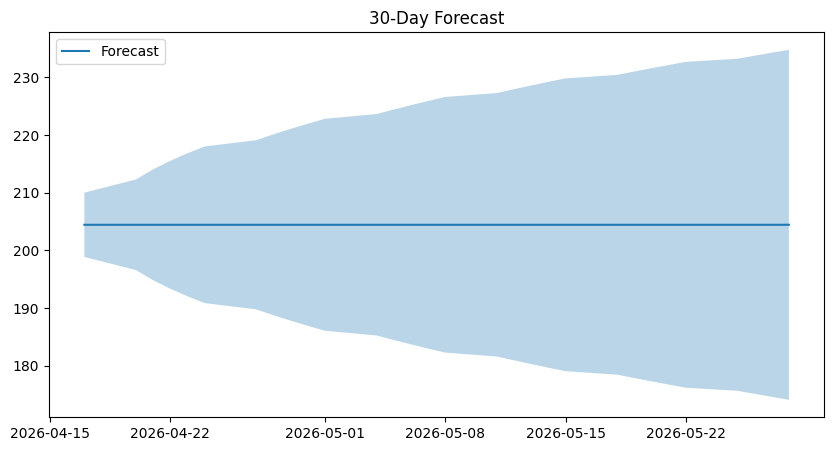

In [32]:
import pandas as pd
from datetime import datetime

# Generate forecast
forecast = model_fit.get_forecast(steps=30)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

# Create date range starting TODAY
today = pd.Timestamp.today().normalize()

future_dates = pd.date_range(start=today, periods=30, freq='B')  # 'B' = business days

# Assign new index
mean_forecast.index = future_dates
conf_int.index = future_dates

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Plot ONLY forecast
plt.plot(mean_forecast.index, mean_forecast, label="Forecast")

# Confidence interval
plt.fill_between(mean_forecast.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 alpha=0.3)

plt.title("30-Day Forecast")
plt.legend()
plt.show()

## Problem 3.4 GARCH Volatility Modeling

In [33]:
sp500 = yf.download("^GSPC", start="2022-01-01", end="2024-12-31")
sp500 = sp500[['Close']].dropna()

[*********************100%***********************]  1 of 1 completed


In [34]:
# Compute returns
import numpy as np

sp500['Returns'] = np.log(sp500['Close'] / sp500['Close'].shift(1))
sp500 = sp500.dropna()

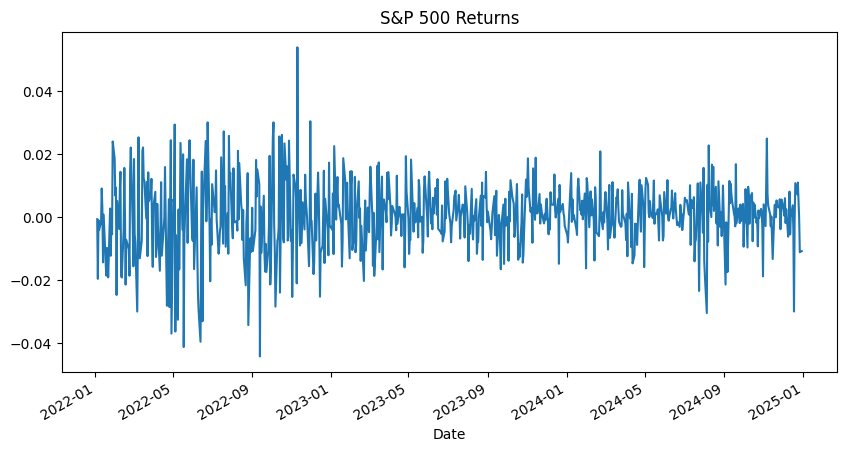

In [35]:
sp500['Returns'].plot(title="S&P 500 Returns", figsize=(10,5))
plt.show()

In [36]:
# Fit GARCH(1,1)
from arch import arch_model

model = arch_model(sp500['Returns']*100, vol='Garch', p=1, q=1)
garch_fit = model.fit(disp='off')

print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1066.14
Distribution:                  Normal   AIC:                           2140.29
Method:            Maximum Likelihood   BIC:                           2158.77
                                        No. Observations:                  751
Date:                Fri, Apr 17 2026   Df Residuals:                      750
Time:                        20:39:48   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0661  3.388e-02      1.951  5.110e-02 [-3.16

In [37]:
# Forecast volatility (20 days)
forecast = garch_fit.forecast(horizon=20)

vol_forecast = forecast.variance.iloc[-1] ** 0.5

print(vol_forecast)

h.01    0.944957
h.02    0.945865
h.03    0.946763
h.04    0.947651
h.05    0.948530
h.06    0.949399
h.07    0.950258
h.08    0.951108
h.09    0.951949
h.10    0.952780
h.11    0.953602
h.12    0.954415
h.13    0.955220
h.14    0.956015
h.15    0.956802
h.16    0.957580
h.17    0.958350
h.18    0.959112
h.19    0.959865
h.20    0.960610
Name: 2024-12-30 00:00:00, dtype: float64


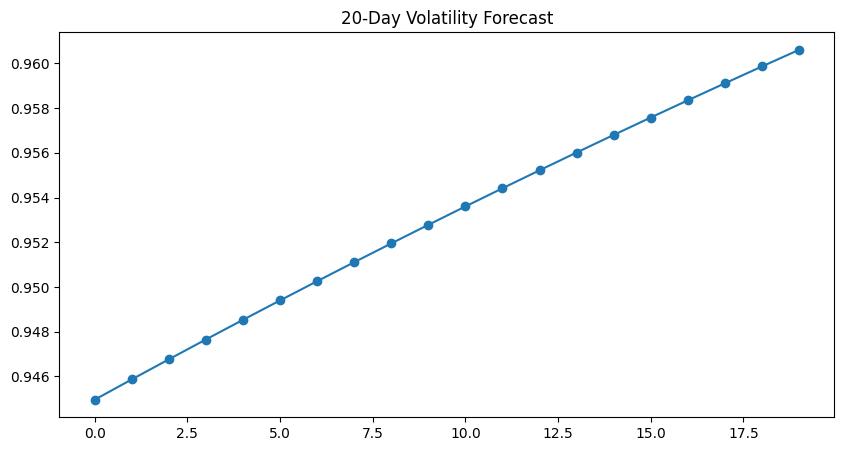

In [38]:
# Plot
plt.figure(figsize=(10,5))
plt.plot(vol_forecast.values, marker='o')
plt.title("20-Day Volatility Forecast")
plt.show()

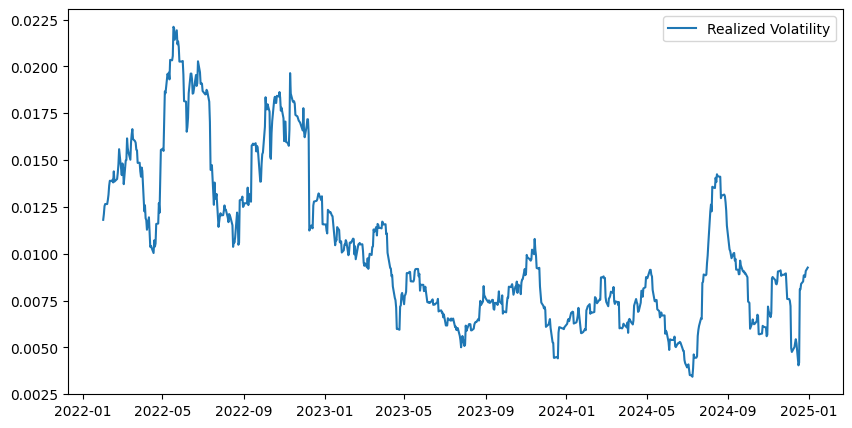

In [39]:
# Validate
# Rolling realized volatility
realized_vol = sp500['Returns'].rolling(window=20).std()

plt.figure(figsize=(10,5))
plt.plot(realized_vol, label="Realized Volatility")
plt.legend()
plt.show()